In [ ]:
import os
import cv2
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

Библиотеки загружены


Загрузка

In [ ]:
# Пути до тестовых объектов
IMAGE_PATH = Path("C:/Recognition_of_agricultural_land_boundaries/1_stage/images/2023_Aleksandrovka_M2000-0-2.jpeg")  # 👈 ВАШ ПУТЬ
JSON_PATH = Path("C:/Recognition_of_agricultural_land_boundaries/1_stage/annotations/2023_Aleksandrovka_M2000-0-2.json")  # 👈 ВАШ ПУТЬ


# ТОЧНЫЙ ЦВЕТ РАЗМЕТКИ (из пипетки)
ANNOTATION_COLOR_BGR = (129, 228, 124)

print(f"Цвет разметки (BGR): {ANNOTATION_COLOR_BGR}")
print(f"Цвет разметки (RGB): (124, 228, 129)")

image = cv2.imread(str(IMAGE_PATH))
with open(JSON_PATH, 'r') as f:
    annotation = json.load(f)

polygons = annotation.get('polygons', [])
print(f"Изображение: {image.shape}")
print(f"Полигонов: {len(polygons)}")

🎨 Цвет разметки (BGR): (129, 228, 124)
🎨 Цвет разметки (RGB): (124, 228, 129)
✅ Изображение: (5000, 5000, 3)
✅ Полигонов: 3


Маска всей области заливки

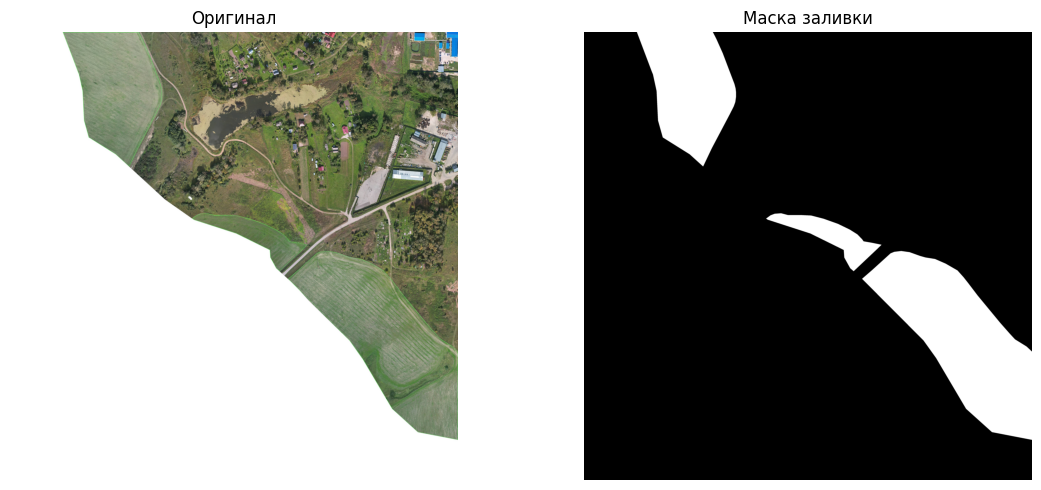

Область заливки: 3199088 пикселей


In [ ]:
def create_fill_mask(image_shape, polygons):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    for polygon in polygons:
        pts = np.array(polygon, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
    return mask

fill_mask = create_fill_mask(image.shape, polygons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинал")
axes[0].axis('off')

axes[1].imshow(fill_mask, cmap='gray')
axes[1].set_title("Маска заливки")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Область заливки: {np.sum(fill_mask > 0)} пикселей")

Маска для обводки (непрозрачной)

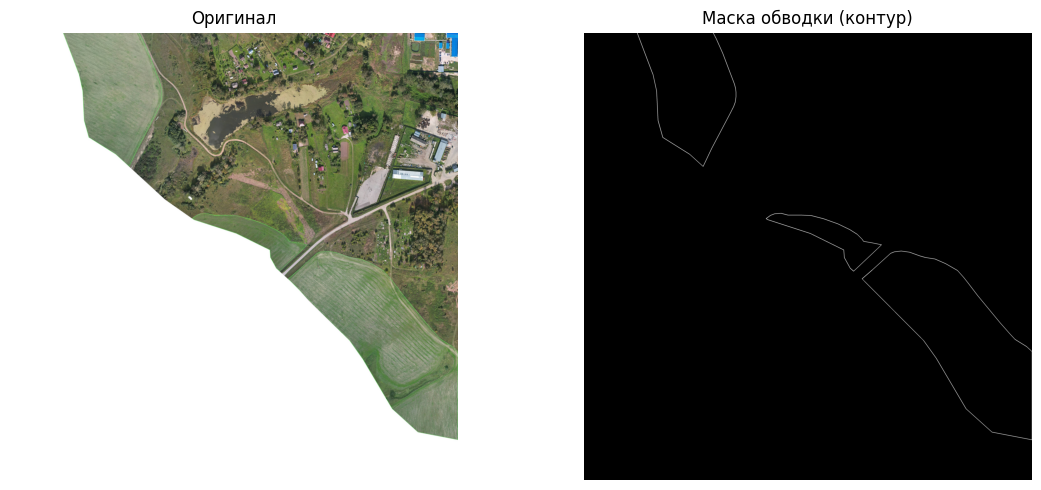

In [ ]:
def create_contour_mask(image_shape, polygons, thickness=2):
    """
    Маска только для контура (обводки)
    """
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    for polygon in polygons:
        pts = np.array(polygon, dtype=np.int32)
        cv2.polylines(mask, [pts], isClosed=True, color=255, thickness=thickness)
    
    return mask

contour_mask = create_contour_mask(image.shape, polygons, thickness=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинал")
axes[0].axis('off')

axes[1].imshow(contour_mask, cmap='gray')
axes[1].set_title("Маска обводки (контур)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Удаление полупрозрачной заливки

📁 Результаты будут сохранены в: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\alpha_test_results
✅ Сохранен оригинал: 00_original.jpg
✅ Сохранена маска: 00_mask.jpg

🔄 Обработка с разными alpha:

✅ alpha = 0.2: сохранен как 01_alpha_0.2.jpg и 01_alpha_0.2.png
✅ alpha = 0.3: сохранен как 02_alpha_0.3.jpg и 02_alpha_0.3.png
✅ alpha = 0.4: сохранен как 03_alpha_0.4.jpg и 03_alpha_0.4.png
✅ alpha = 0.5: сохранен как 04_alpha_0.5.jpg и 04_alpha_0.5.png
✅ alpha = 0.6: сохранен как 05_alpha_0.6.jpg и 05_alpha_0.6.png
✅ alpha = 0.7: сохранен как 06_alpha_0.7.jpg и 06_alpha_0.7.png

📁 Все результаты сохранены в папку: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\alpha_test_results

📌 Инструкция:
   1. Откройте папку с результатами
   2. Просмотрите изображения с разными alpha
   3. Выберите alpha, при котором заливка исчезла лучше всего
   4. Запишите выбранное значение alpha ниже


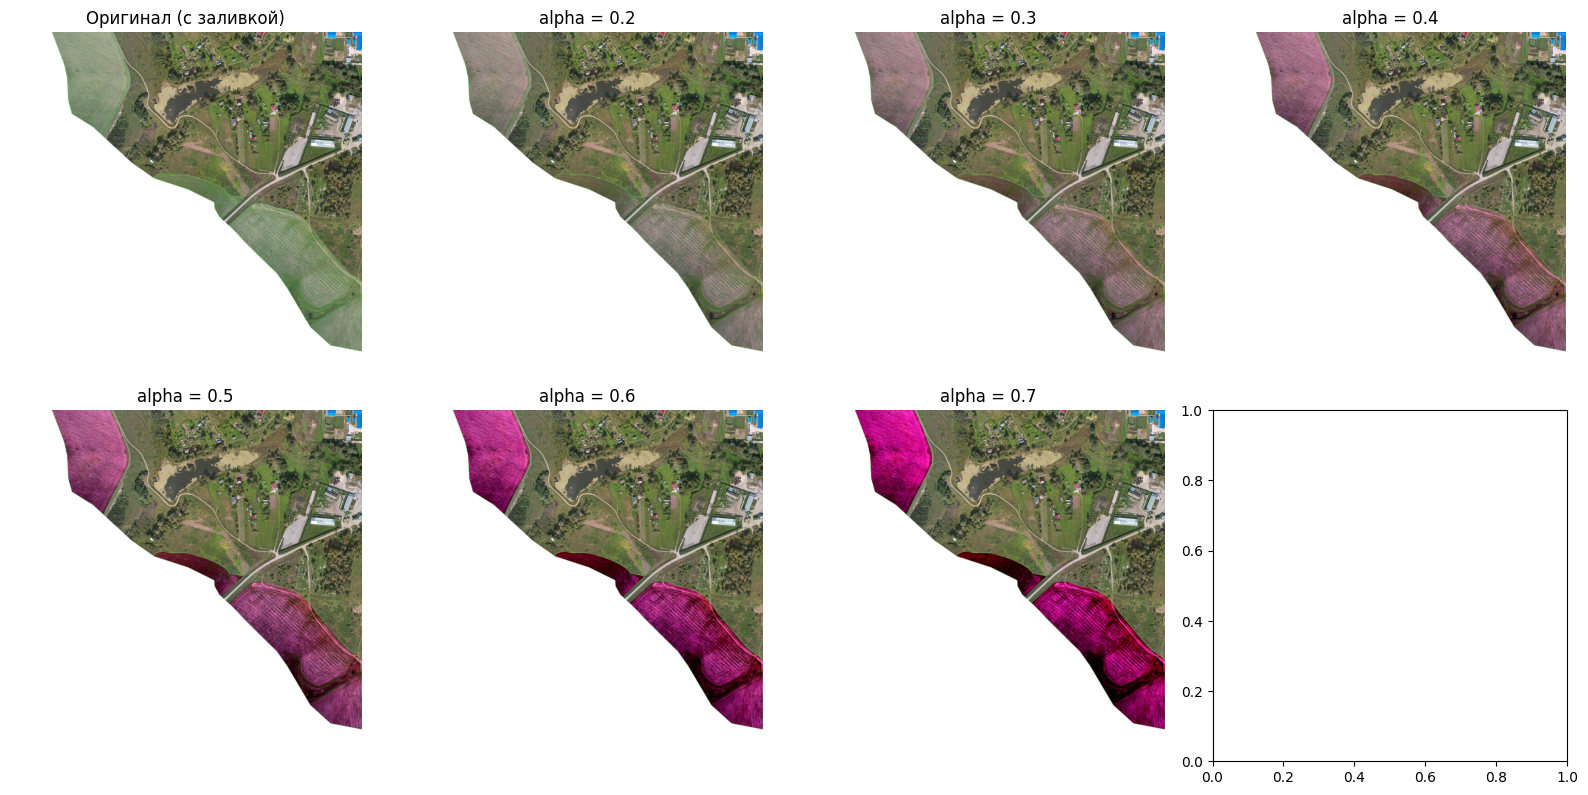


👉 Введите выбранное значение alpha в следующей ячейке


In [ ]:
def remove_transparent_fill_known_color(image, mask, fill_color, alpha):
    """
    Удаляет заливку по формуле смешивания
    fill_color - цвет заливки (BGR)
    alpha - прозрачность (0-1)
    """
    result = image.copy().astype(np.float32)
    fill_norm = np.array(fill_color, dtype=np.float32)
    
    mask_indices = mask > 0
    
    for c in range(3):
        # Формула: original = (result - fill_color * alpha) / (1 - alpha)
        result[mask_indices, c] = (result[mask_indices, c] - fill_norm[c] * alpha) / (1 - alpha)
    
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

OUTPUT_ALPHA_DIR = Path("./alpha_test_results")
OUTPUT_ALPHA_DIR.mkdir(exist_ok=True)

print(f"Результаты будут сохранены в: {OUTPUT_ALPHA_DIR.absolute()}")

# Пробуем разные alpha
alphas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

original_path = OUTPUT_ALPHA_DIR / "00_original.jpg"
cv2.imwrite(str(original_path), image)

mask_path = OUTPUT_ALPHA_DIR / "00_mask.jpg"
cv2.imwrite(str(mask_path), fill_mask)

for i, alpha in enumerate(alphas):
    result = remove_transparent_fill_known_color(image, fill_mask, ANNOTATION_COLOR_BGR, alpha)
    
    result_filename = f"{(i+1):02d}_alpha_{alpha}.jpg"
    result_path = OUTPUT_ALPHA_DIR / result_filename
    cv2.imwrite(str(result_path), result)
    
    png_filename = f"{(i+1):02d}_alpha_{alpha}.png"
    png_path = OUTPUT_ALPHA_DIR / png_filename
    cv2.imwrite(str(png_path), result)
    
    print(f"alpha = {alpha}: сохранен как {result_filename} и {png_filename}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинал (с заливкой)")
axes[0].axis('off')

for i, alpha in enumerate(alphas):
    result = remove_transparent_fill_known_color(image, fill_mask, ANNOTATION_COLOR_BGR, alpha)
    axes[i+1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[i+1].set_title(f"alpha = {alpha}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()